# Hand classifier

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

C:\Users\Omistaja\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


tensorflow


In [2]:
from sklearn.model_selection import train_test_split
batch_size_n = 4
img_size = (224, 224)

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    'images/train',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    label_mode='categorical',
    validation_split=0.177, # ensures validation and test sets are equal size
    subset='both',
    shuffle=True,
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    'images/test',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    shuffle=False,
    label_mode='categorical')

Found 255 files belonging to 5 classes.
Using 210 files for training.
Using 45 files for validation.
Found 45 files belonging to 5 classes.


In [3]:
import tensorflow as tf
from keras.applications import VGG16
from keras import Sequential
from keras import layers
from keras.optimizers import Adam
num_classes = 5

conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [4]:
from keras.applications.vgg16 import preprocess_input

def preprocess(images):
    return preprocess_input(tf.cast(images, tf.float32))

In [5]:
# code from https://deeplearningwithpython.io/chapters/chapter08_image-classification/#using-a-pretrained-model
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = preprocess(images)
        features = conv_base.predict(preprocessed_images, verbose=0)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [6]:
model = Sequential([
    layers.Input(shape=(7, 7, 512)),
    data_augmentation,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    train_features,
    train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks,
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2000 - loss: 3.9175 - val_accuracy: 0.3556 - val_loss: 1.8940
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4000 - loss: 1.9920 - val_accuracy: 0.4222 - val_loss: 1.4879
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4286 - loss: 1.8180 - val_accuracy: 0.5333 - val_loss: 1.2011
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4714 - loss: 1.3569 - val_accuracy: 0.5111 - val_loss: 1.1312
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5857 - loss: 1.0690 - val_accuracy: 0.6000 - val_loss: 1.1189
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6333 - loss: 0.8808 - val_accuracy: 0.6222 - val_loss: 0.9676
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6571 - loss: 0.8812 - val_accuracy: 0.6000 - val_loss: 0.9897
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7000 - loss: 0.7663 - val_accuracy: 0.6222 - val_loss: 0.9440
Epoch 9

In [8]:
images = []
labels = []
class_names = ['1 finger', '2 fingers', '3 fingers', '4 fingers', '5 fingers']

for image_batch, label_batch in test_dataset:
    images.append(image_batch.numpy())
    labels.append(label_batch.numpy())

images = np.concatenate(images)
labels = np.concatenate(labels)

In [9]:
def show_example_images_and_predictions(predicted_labels):
    plt.figure(figsize=(15, 8))
    
    for i in range(20):
        plt.subplot(4, 5, i + 1)
    
        plt.imshow(images[i].astype("uint8"))
    
        true_label = y_true_classes[i]
        pred_label = predicted_labels[i]
    
        color = "green" if true_label == pred_label else "red"
    
        plt.title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            color=color
        )
    
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

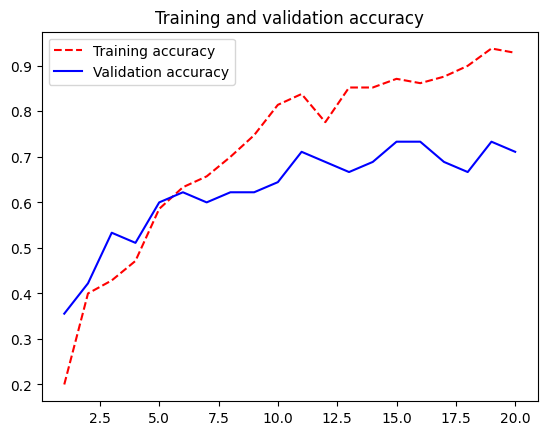

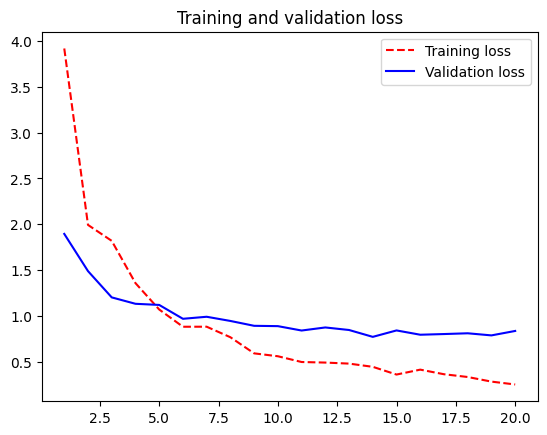

In [10]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [11]:
loss, acc = model.evaluate(test_features, test_labels, verbose=0)
print(f"The model's test accuracy is {acc}")

The model's test accuracy is 0.6000000238418579


In [13]:
y_pred = model.predict(test_features)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(np.concatenate([y for x, y in test_dataset], axis=0), axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


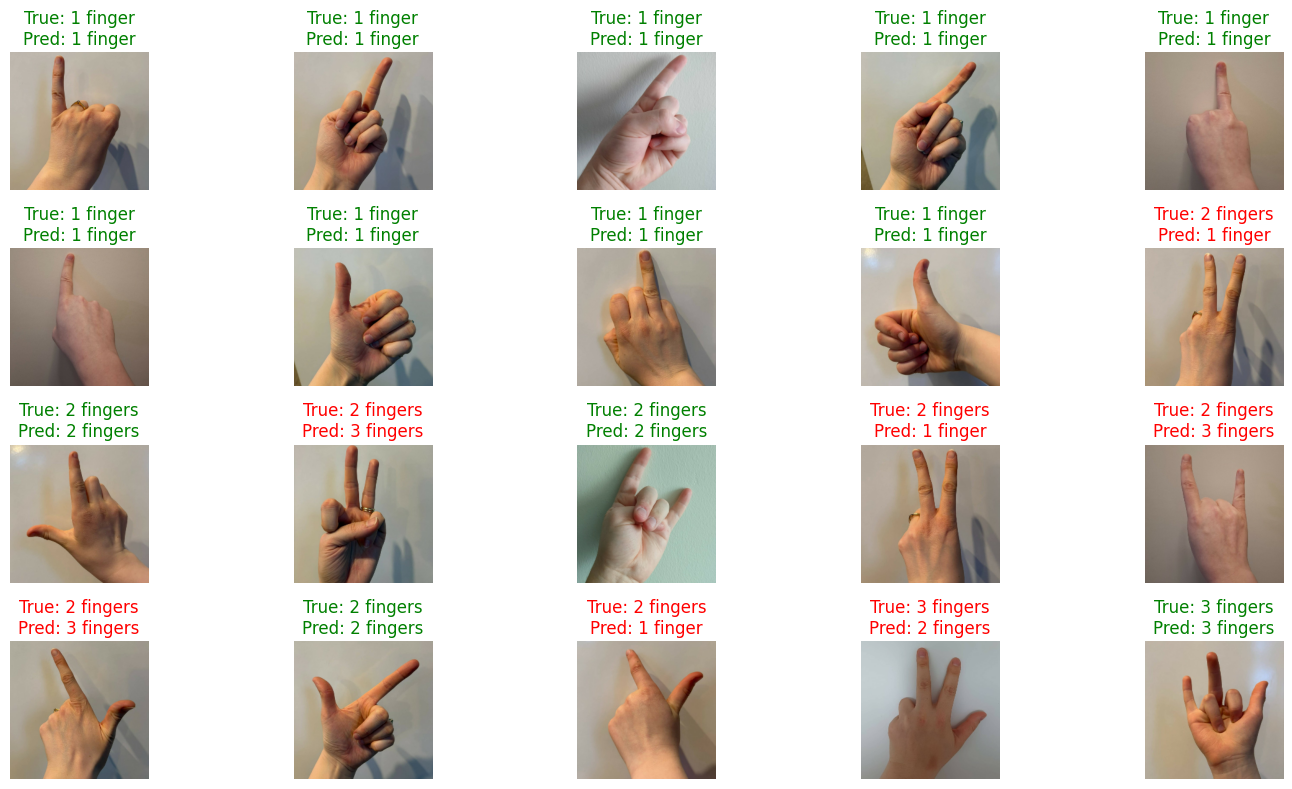

In [14]:
y_pred = model.predict(test_features)
y_pred_classes = np.argmax(y_pred, axis=1)
show_example_images_and_predictions(y_pred_classes)